In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm, trange
import yaml
import os

# ensure seaborn is available; install into current Python if missing
try:
    import seaborn as sns
    sns.set_theme()
except Exception:
    import sys, subprocess
    print("seaborn not found — installing into current Python environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"]) 
    import seaborn as sns
    sns.set_theme()

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from model import NARX_Transformer
from dataset import load_NASA

# Load the YAML configuration file
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

# # Access the variables
NUM_CYCLES = cfg['NUM_CYCLES']
NUM_PREDS = cfg['NUM_PREDS']
FEATURE_DIM1 = cfg['FEATURE_DIM1']
FEATURE_DIM2 = cfg['FEATURE_DIM2']
NUM_ATTENTION = cfg['NUM_ATTENTION']
EPOCHS = cfg['EPOCHS']
LEARNING_RATE = cfg['LEARNING_RATE']
BATCH_SIZE = cfg['BATCH_SIZE']

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
train_dataset, test_dataset = load_NASA(folder='NASA_DATA', num_cycles=NUM_CYCLES+NUM_PREDS-1, split_ratio=0.5, scale_data=True)

# Train/test split
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

 # NN model (yorum satırı haline getirildi)
model = NARX_Transformer(feature_dim1=FEATURE_DIM1,
                          feature_dim2=FEATURE_DIM2,
                          num_attention=NUM_ATTENTION,
                          num_cycles=NUM_CYCLES,
                          num_preds=NUM_PREDS).to(device)

#Loss function and optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ## Training loop kısmını yorum satırına aldım sonuçları görmek için baştan eğitime başlamaması için
# best_epoch = 0
# best_loss = float('inf')
# Loss_log = []
# os.makedirs('models', exist_ok=True)
# model.train()
# t_range = trange(EPOCHS)
# for epoch in t_range:
#     train_losses = []
#     for inputs, outputs in train_dataloader:
#         inputs = inputs.float().to(device)
#         outputs = outputs.float().to(device)
#         predicted_outputs = model.pred_sequence(inputs, outputs)
#
#         optimizer.zero_grad()
#         loss = criterion(predicted_outputs[:,NUM_CYCLES-1:], outputs[:,NUM_CYCLES-1:])
#         loss.backward()
#         optimizer.step()
#         train_losses.append(loss.item())
#
#     test_losses = []
#     for inputs, outputs in test_dataloader:
#         inputs = inputs.float().to(device)
#         outputs = outputs.float().to(device)
#         with torch.no_grad():
#             predicted_outputs = model.pred_sequence(inputs, outputs)
#             test_loss = criterion(predicted_outputs[:,NUM_CYCLES-1:], outputs[:,NUM_CYCLES-1:])
#             test_losses.append(test_loss.item())
#     Loss_log.append([np.mean(train_losses),np.mean(test_losses)])
#     # Print the loss for monitoring after each epoch
#     t_range.set_description(f"train loss: {np.mean(train_losses)}, test loss: {np.mean(test_losses)}")
#     t_range.refresh()
#
#     # Check if the current loss is the best so far
#     if np.mean(test_losses) < best_loss:
#         best_epoch = epoch
#         best_loss = np.mean(test_losses)
#         torch.save(model, f'models/trained_model_{best_loss:.6f}_{best_epoch}.pt')
#
# Loss_log = np.array(Loss_log)
# np.save(f'models/training_log_{NUM_CYCLES}_{NUM_PREDS}.npy', Loss_log)
#
# plt.figure(figsize=(8,5))
# plt.plot(Loss_log[:,0])
# plt.plot(Loss_log[:,1])
# plt.legend(["Train Loss","Test Loss"])
# plt.grid("on")
# plt.xlabel("Step")
# plt.ylabel("Loss")
# plt.show()

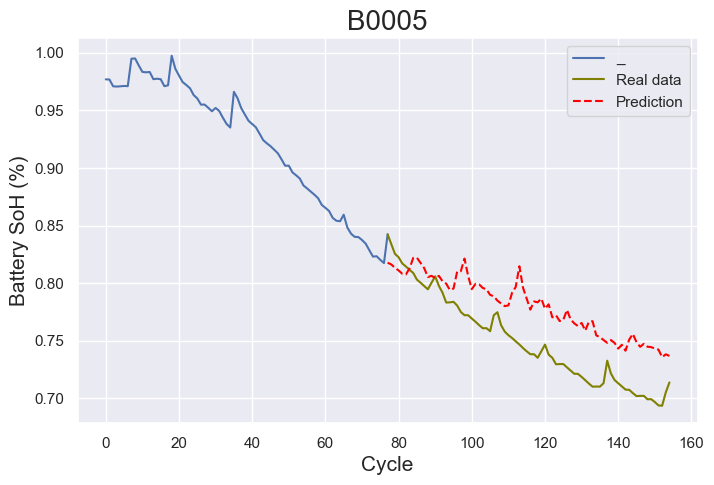

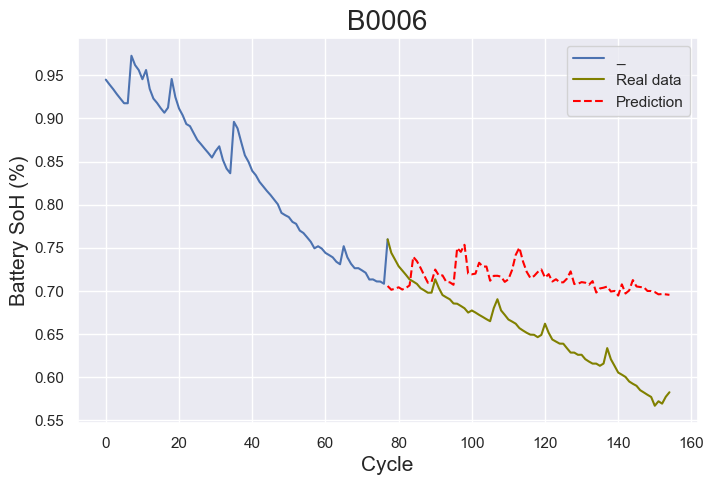

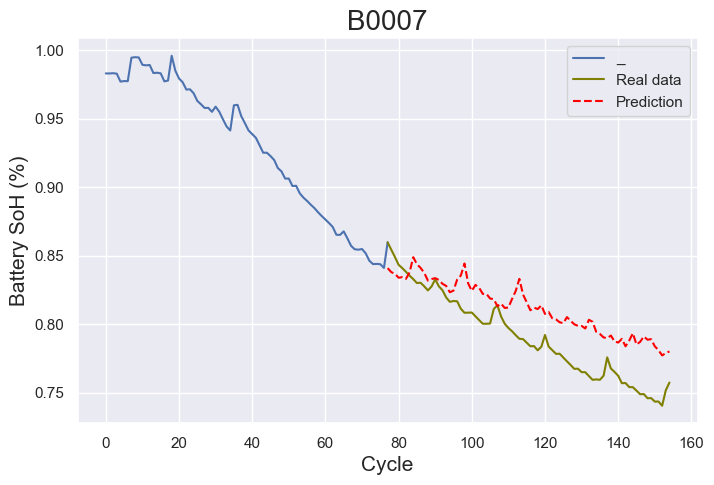

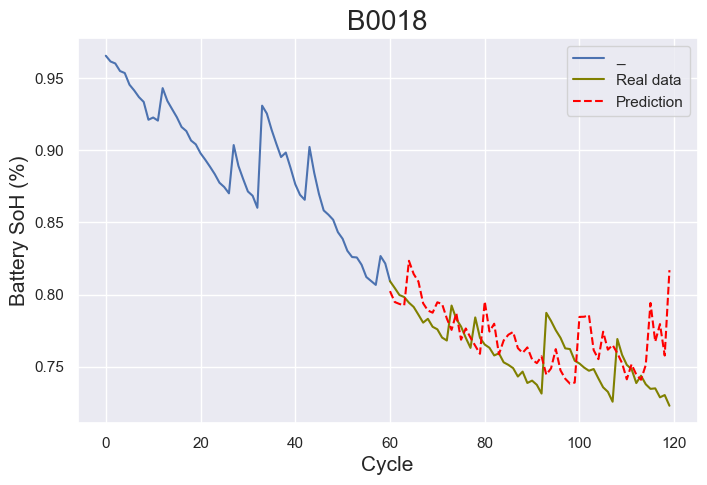

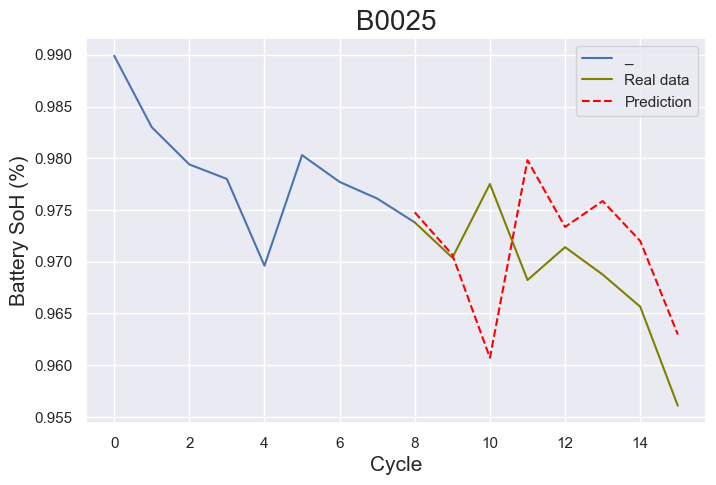

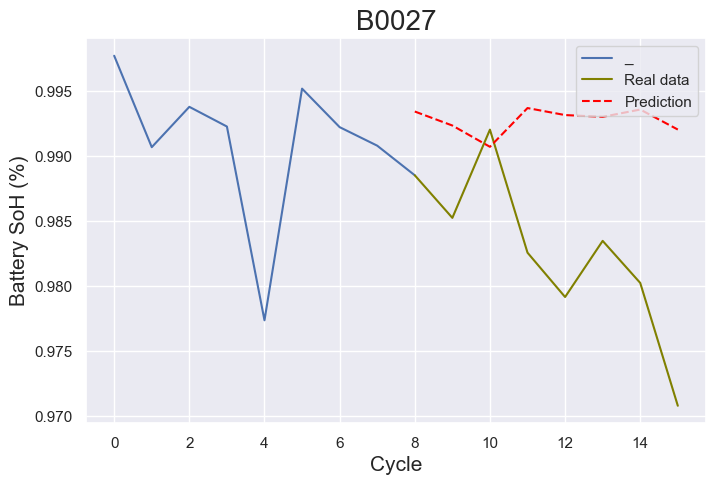

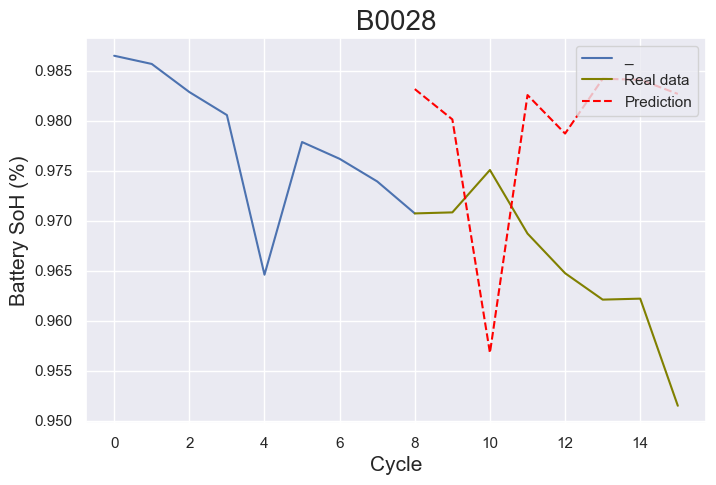

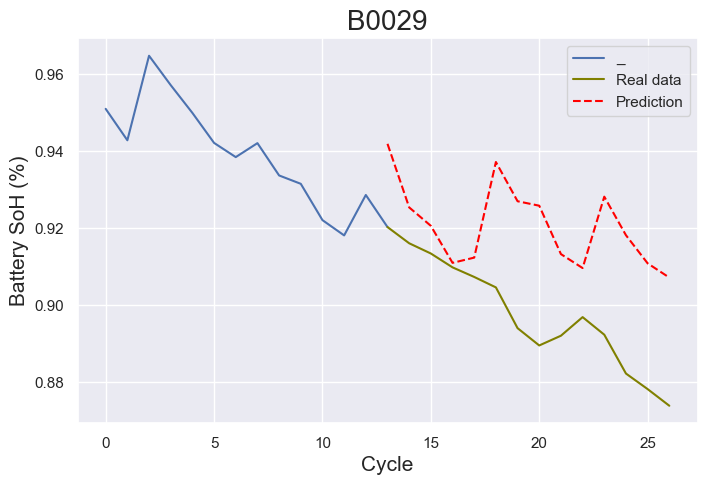

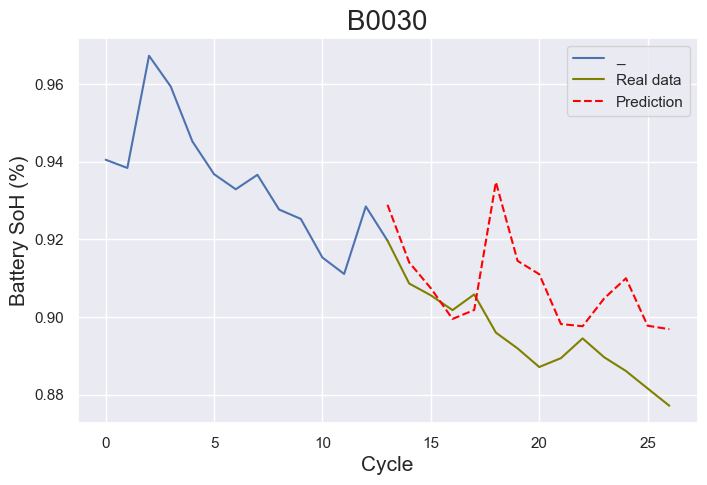

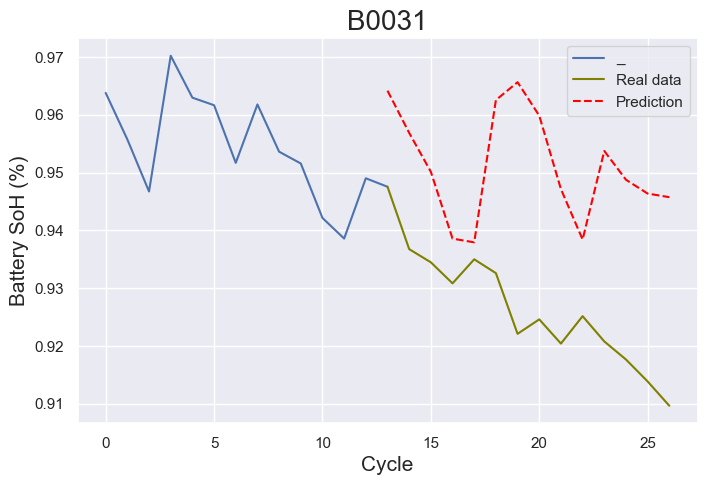

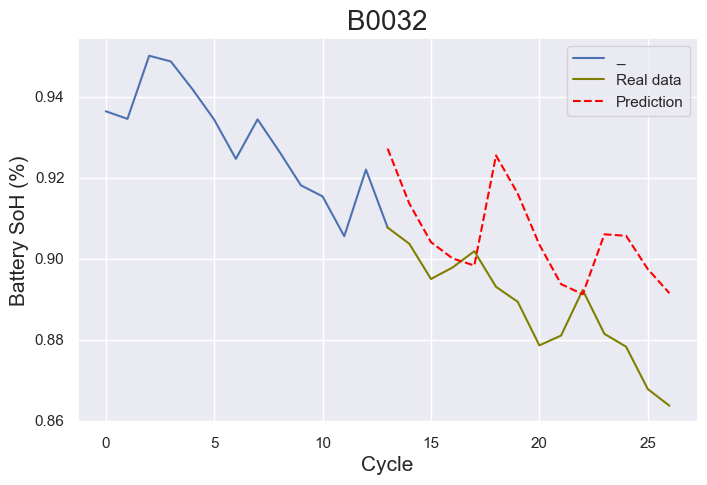

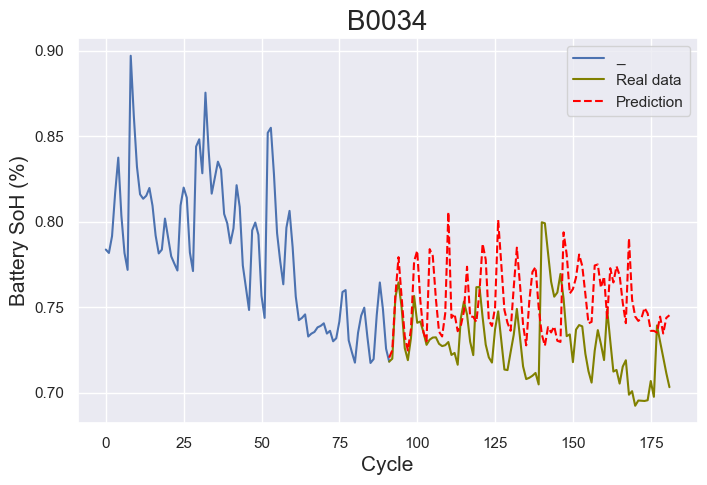

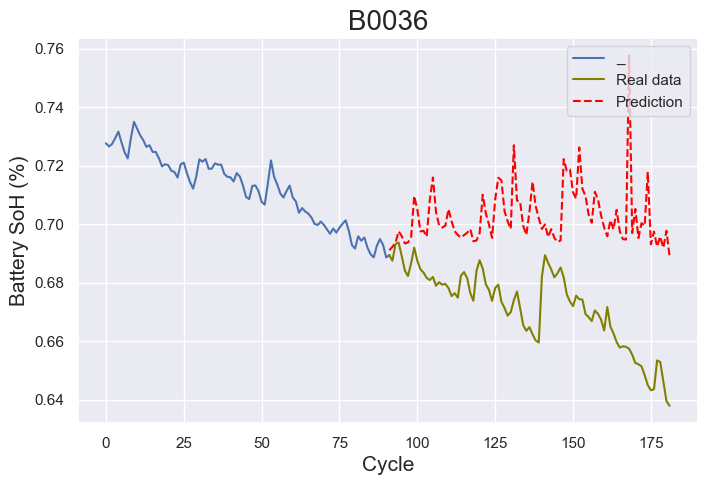

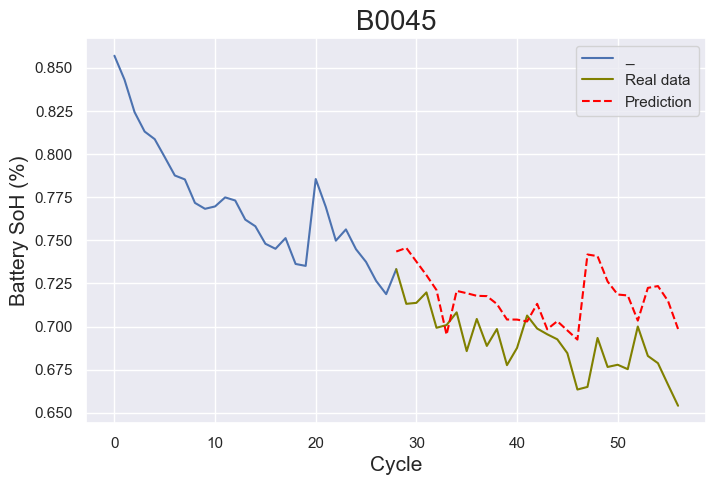

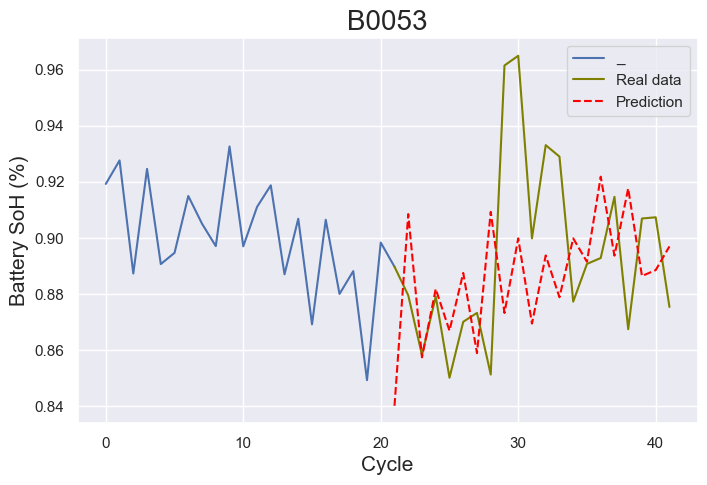

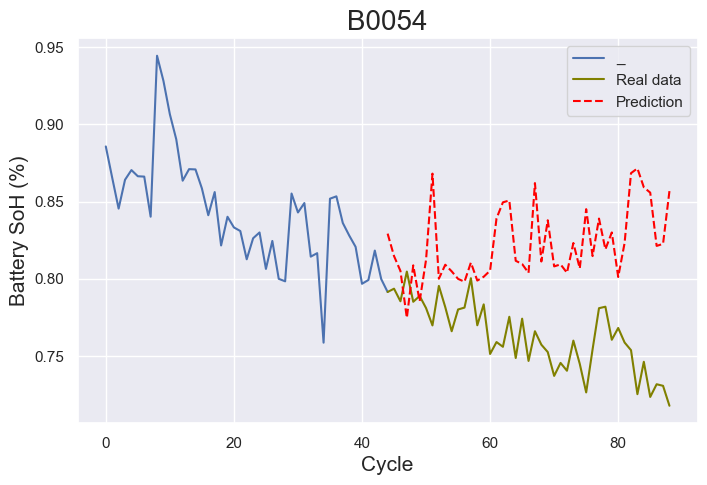

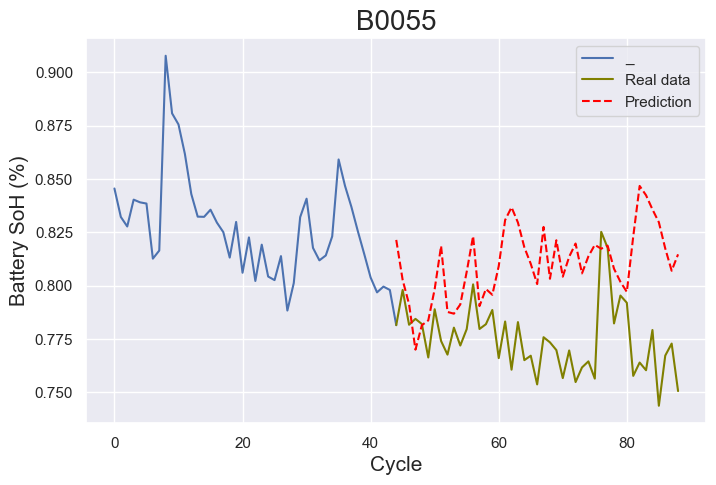

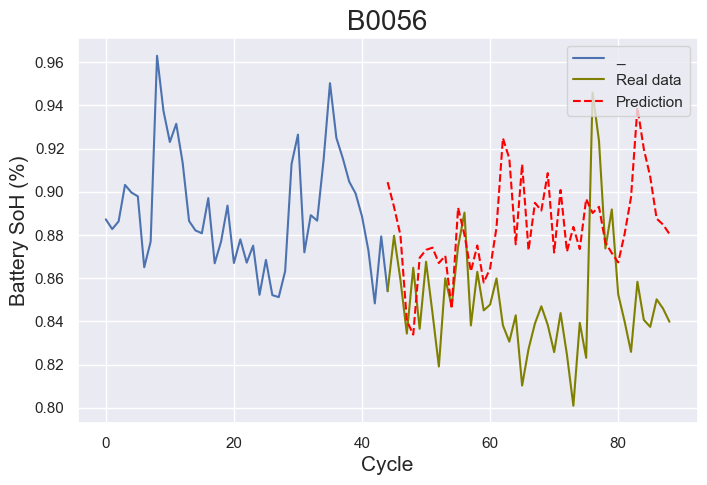

In [ ]:
from assets.plots import plot_predicted_capacity

# Load model from the provided absolute path
model_path = r"C:\Users\TR\Desktop\NARX-Transformer-SoH-main\models\trained_model_0.017068_763.pt"
# This file contains a pickled model object; allow full unpickling (weights_only=False)
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

evaluations = plot_predicted_capacity(model, train_dataset, test_dataset, NUM_CYCLES)

B0005 - 78 - MSE:0.001267, RMSE:0.035595, MAE:0.032229, MAX_ERR:0.067952
B0006 - 78 - MSE:0.005549, RMSE:0.074493, MAE:0.066269, MAX_ERR:0.131777
B0007 - 78 - MSE:0.000672, RMSE:0.025917, MAE:0.023084, MAX_ERR:0.043731
B0018 - 60 - MSE:0.000660, RMSE:0.025699, MAE:0.020453, MAX_ERR:0.093939
B0025 - 8 - MSE:0.000070, RMSE:0.008359, MAE:0.006489, MAX_ERR:0.016792
B0027 - 8 - MSE:0.000139, RMSE:0.011808, MAE:0.010318, MAX_ERR:0.021237
B0028 - 8 - MSE:0.000363, RMSE:0.019041, MAE:0.017870, MAX_ERR:0.031177
B0029 - 14 - MSE:0.000676, RMSE:0.025997, MAE:0.022703, MAX_ERR:0.036299
B0030 - 14 - MSE:0.000304, RMSE:0.017435, MAE:0.013912, MAX_ERR:0.038736
B0031 - 14 - MSE:0.000738, RMSE:0.027161, MAE:0.024599, MAX_ERR:0.043535
B0032 - 14 - MSE:0.000438, RMSE:0.020931, MAE:0.017963, MAX_ERR:0.032448
B0034 - 91 - MSE:0.001374, RMSE:0.037073, MAE:0.031511, MAX_ERR:0.091438
B0036 - 91 - MSE:0.001208, RMSE:0.034749, MAE:0.030429, MAX_ERR:0.100208
B0045 - 29 - MSE:0.001005, RMSE:0.031709, MAE:0.026243

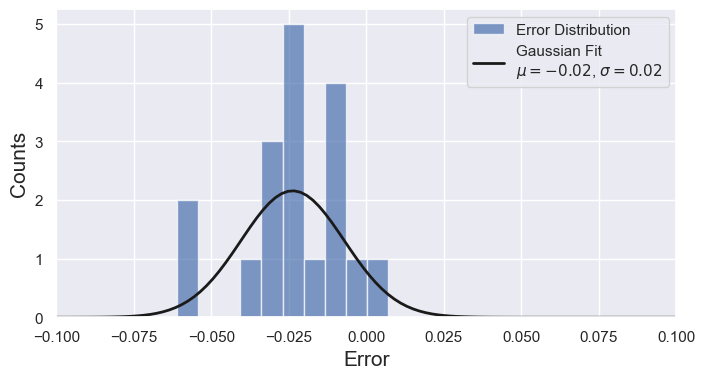

In [ ]:
from assets.metrics import report_metrics
from assets.plots import plot_error_histogram

MSEs = []
RMSEs = []
MAEs = []
MAX_ERRs = []
errors = [] 
for name, label, pred in evaluations:
    error = label - pred
    MSE, RMSE, MAE, MAX_ERR = report_metrics(label, pred)
    print(f"{name} - {len(pred)} - MSE:{MSE:.6f}, RMSE:{RMSE:.6f}, MAE:{MAE:.6f}, MAX_ERR:{MAX_ERR:.6f}")

    MSEs.append(MSE)
    RMSEs.append(RMSE)
    MAEs.append(MAE)
    MAX_ERRs.append(MAX_ERR)
    errors.append(np.mean(error))


print(f"Average - MSE:{np.mean(MSEs):.6f}, RMSE:{np.mean(RMSEs):.6f}, MAE:{np.mean(MAEs):.6f}, MAX_ERR:{np.mean(MAX_ERRs):.6f}")
plot_error_histogram(errors)

In [ ]:
sum(p.numel() for p in model.parameters())

142097

In [ ]:
np.sqrt(0.000491)

np.float64(0.022158519806160338)